2025-12-11 15:56:00.356499: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-12-11 15:56:01.017791: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-12-11 15:56:04.578131: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


Generating synthetic CICIDS2017-like data...
Data Loaded. Shape: (10000, 79)
Class Distribution:
 Label
BENIGN      8000
DoS Hulk    2000
Name: count, dtype: int64

 Preprocessing Data...
Training set size: (8000, 78) (Normal samples used for AE training: (6400, 78))
Test set size: (2000, 78)

 Building and Training Baseline Autoencoder...


2025-12-11 15:56:05.679477: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Epoch 1/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0604 - val_loss: 0.0034
Epoch 2/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0027 - val_loss: 0.0026
Epoch 3/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0026 - val_loss: 0.0026
Epoch 4/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0026 - val_loss: 0.0026
Epoch 5/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0026 - val_loss: 0.0026
Epoch 6/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0026 - val_loss: 0.0026
Epoch 7/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0026 - val_loss: 0.0025
Epoch 8/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0025 - val_loss: 0.0025
Epoch 9/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0025 - val_loss: 0.0025
Epoch 10/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0025 - val_loss: 0.0025
Epoch 11/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0024 - val_loss: 0.0024
Epoch 12/20
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0024 - val_lo

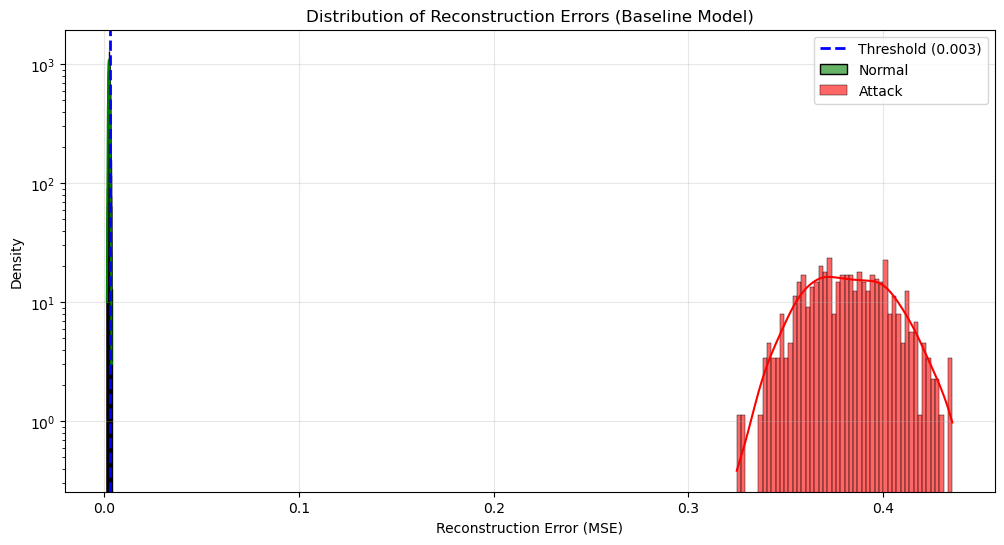

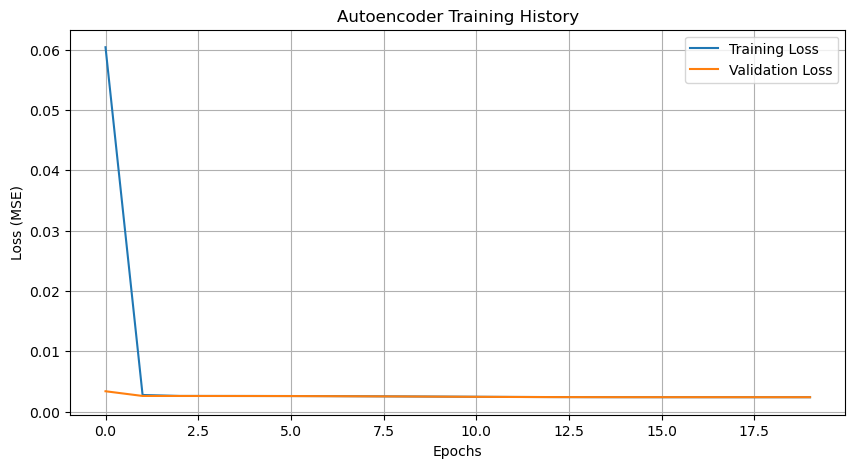

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.ensemble import RandomForestClassifier

# ==========================================
# CONFIGURATION
# ==========================================
# Set this to True if you have the dataset downloaded locally
USE_REAL_DATA = False 
DATASET_PATH = 'CICIDS2017_sample.csv' # Path to your dataset

# Hyperparameters
INPUT_DIM = 78 # CICIDS2017 typically has ~78-80 usable features
LATENT_DIM = 8 # Size of the bottleneck layer (Compressed representation)
EPOCHS = 20
BATCH_SIZE = 64
RANDOM_SEED = 42

np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

# ==========================================
# 1. DATA LOADING & GENERATION
# ==========================================
def generate_dummy_data(n_samples=10000):
    """
    Generates a synthetic dataset mimicking the structure of CICIDS2017
    for testing the code logic.
    """
    print("Generating synthetic CICIDS2017-like data...")
    # Normal traffic (80%) - Lower values, specific patterns
    n_normal = int(n_samples * 0.8)
    normal_data = np.random.normal(loc=0.1, scale=0.05, size=(n_normal, INPUT_DIM))
    
    # Attack traffic (20%) - Higher values, different distribution (e.g., DoS)
    n_attack = n_samples - n_normal
    attack_data = np.random.normal(loc=0.6, scale=0.15, size=(n_attack, INPUT_DIM))
    
    # Combine
    X = np.vstack([normal_data, attack_data])
    # Clip to ensure valid range for simulation
    X = np.clip(X, 0, 1) 
    
    # Labels: 'BENIGN' for normal, 'DoS Hulk' for attacks
    y = np.array(['BENIGN'] * n_normal + ['DoS Hulk'] * n_attack)
    
    # Shuffle
    indices = np.arange(n_samples)
    np.random.shuffle(indices)
    
    df = pd.DataFrame(X[indices], columns=[f'Feature_{i}' for i in range(INPUT_DIM)])
    df['Label'] = y[indices]
    
    return df

def load_data():
    if USE_REAL_DATA:
        print(f"Loading real dataset from {DATASET_PATH}...")
        # Reading data (Handling potential spaces in column names common in CICIDS)
        df = pd.read_csv(DATASET_PATH)
        df.columns = df.columns.str.strip() 
        return df
    else:
        return generate_dummy_data()

# Load the data
df = load_data()
print(f"Data Loaded. Shape: {df.shape}")
print("Class Distribution:\n", df['Label'].value_counts())

# ==========================================
# 2. DATA PREPROCESSING
# ==========================================
print("\n Preprocessing Data...")

# 2.1 Cleaning
# Replace Infinity with NaN and drop NaNs
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

# 2.2 Encoding Labels
# We need binary labels for Anomaly Detection (0 = Normal, 1 = Attack)
# In CICIDS2017, 'BENIGN' is normal.
# FIX: Update the column in place, do not overwrite 'df'
df['Label'] = df['Label'].apply(lambda x: 0 if x == 'BENIGN' else 1)

# 2.3 Splitting Features and Target
# FIX: Added ['Label'] to the drop function
X = df.drop(columns=['Label'])
y = df['Label']

# 2.4 Train/Test Split
# We split normally first to get a representative Test Set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y)

# 2.5 Normalization (Min-Max Scaling)
# Crucial for Autoencoders to map inputs to a 0-1 range (matching Sigmoid output)
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2.6 Filter Normal Data for Autoencoder Training
# Autoencoders for anomaly detection are trained ONLY on benign traffic
train_index_normal = np.where(y_train == 0)
X_train_normal = X_train_scaled[train_index_normal]

print(f"Training set size: {X_train_scaled.shape} (Normal samples used for AE training: {X_train_normal.shape})")
print(f"Test set size: {X_test_scaled.shape}")

# ==========================================
# 3. METHOD A: BASELINE AUTOENCODER
# ==========================================
print("\n Building and Training Baseline Autoencoder...")

# 3.1 Define Architecture (Deep Autoencoder)
input_layer = Input(shape=(INPUT_DIM,))

# Encoder
encoded = Dense(64, activation='relu')(input_layer)
encoded = Dense(32, activation='relu')(encoded)
bottleneck = Dense(LATENT_DIM, activation='relu')(encoded) # Latent Space

# Decoder
decoded = Dense(32, activation='relu')(bottleneck)
decoded = Dense(64, activation='relu')(decoded)
output_layer = Dense(INPUT_DIM, activation='sigmoid')(decoded) # Output scaled 0-1

# Create Model
autoencoder = Model(inputs=input_layer, outputs=output_layer)
autoencoder.compile(optimizer='adam', loss='mse')

# 3.2 Train (Unsupervised - X is both input and target)
history = autoencoder.fit(
    X_train_normal, X_train_normal,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,
    validation_split=0.1,
    verbose=1
)

# 3.3 Detect Anomalies (Reconstruction Error)
print("Calculating reconstruction errors...")
# Get reconstruction for the test set
X_test_pred = autoencoder.predict(X_test_scaled)
# Calculate Mean Squared Error per sample
mse = np.mean(np.power(X_test_scaled - X_test_pred, 2), axis=1)

# 3.4 Determine Threshold
# Simple statistical threshold: Mean + 2 * StdDev of the Normal Training Errors
# (Or we can use the errors from the test set normal samples to be safer)
threshold = np.mean(mse[y_test==0]) + 2 * np.std(mse[y_test==0])
print(f"Anomaly Threshold: {threshold:.4f}")

# 3.5 Classification
y_pred_baseline = [1 if e > threshold else 0 for e in mse]

# ==========================================
# 4. METHOD B: HYBRID MODEL (NOVELTY)
# ==========================================
print("\n Training Novelty Hybrid Model (AE + Random Forest)...")

# 4.1 Feature Extraction using Encoder
# We create a separate model that just outputs the bottleneck layer
encoder_model = Model(inputs=autoencoder.input, outputs=bottleneck)

# Encode all training data (both normal and attack)
# Note: For the hybrid classifier, we use the FULL training set, not just normal
X_train_encoded = encoder_model.predict(X_train_scaled)
X_test_encoded = encoder_model.predict(X_test_scaled)

print(f"Original Feature Shape: {X_train_scaled.shape}")
print(f"Encoded Feature Shape: {X_train_encoded.shape} (Dimensionality Reduced)")

# 4.2 Train Random Forest on Compressed Features
rf_clf = RandomForestClassifier(n_estimators=100, random_state=RANDOM_SEED)
rf_clf.fit(X_train_encoded, y_train)

# 4.3 Predict
y_pred_hybrid = rf_clf.predict(X_test_encoded)

# ==========================================
# 5. EVALUATION & VISUALIZATION
# ==========================================
print("\n Comparative Evaluation...")

def print_metrics(y_true, y_pred, name):
    print(f"--- {name} Performance ---")
    print(f"Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"Recall:    {recall_score(y_true, y_pred):.4f}")
    print(f"F1-Score:  {f1_score(y_true, y_pred):.4f}")
    print("\nConfusion Matrix:\n", confusion_matrix(y_true, y_pred))
    print("-" * 30)

print_metrics(y_test, y_pred_baseline, "Baseline (Reconstruction Error)")
print_metrics(y_test, y_pred_hybrid, "Hybrid (Encoder + RF)")

# 5.1 Visualization: Reconstruction Error Histogram
plt.figure(figsize=(12, 6))
sns.histplot(mse[y_test==0], bins=50, kde=True, color='green', label='Normal', stat='density', alpha=0.6)
sns.histplot(mse[y_test==1], bins=50, kde=True, color='red', label='Attack', stat='density', alpha=0.6)
plt.axvline(threshold, color='blue', linestyle='--', linewidth=2, label=f'Threshold ({threshold:.3f})')
plt.title('Distribution of Reconstruction Errors (Baseline Model)')
plt.xlabel('Reconstruction Error (MSE)')
plt.ylabel('Density')
plt.legend()
plt.yscale('log') # Log scale is often better for seeing the tail of attacks
plt.grid(True, alpha=0.3)
plt.show()

# 5.2 Visualization: Model Training Loss
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Autoencoder Training History')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()